# embodied-sync — catching timestamp bugs before they poison your policy

A manipulation policy consumes observation frames stitched together from sensors
that disagree about time: cameras at 30 Hz on their own hardware clocks,
proprioception at 250 Hz, tactile at 60 Hz, all delivered with different (and
drifting) latencies. Small sync errors are **silent dataset poison** — the policy
trains on one temporal alignment and deploys on another, and nothing in the
usual tooling (LeRobot, rosbag, XDF) ever checks.

`embodied-sync` is a validation layer for exactly this. Its core loop:

1. **Synthesize** a deterministic multi-stream "truth world" (or import your run);
2. **Corrupt** it with *known* jitter, latency, drift, drops, stalls;
3. **Align** it into fixed-rate, policy-ready frames with per-frame skew and
   confidence metadata;
4. **Report** sync quality — and cross-check what the aligner *detected* against
   the corruption *ground truth*.

Everything is integer-nanosecond, seeded, and byte-reproducible. This notebook
runs the whole loop in-memory in ~10 seconds with only `numpy`, `pyyaml`, and
`matplotlib`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt

from embodied_sync.streams.synthetic import generate_synthetic_run
from embodied_sync.corrupt.profile import load_profile
from embodied_sync.corrupt.apply import apply_profile
from embodied_sync.align.engine import align_run
from embodied_sync.align.ring_buffer import StreamRingBuffer
from embodied_sync.align.online import MultiStreamAligner
from embodied_sync.reports.sync_quality import build_report, save_report_html

REPO = Path.cwd().parents[1] if (Path.cwd() / "..").resolve().name == "examples" else Path.cwd()
MS = 1_000_000  # ns per ms

# Chart chrome + a fixed per-stream color (color follows the stream everywhere).
SURFACE, INK, INK2, MUTED = "#fcfcfb", "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE, CRITICAL = "#e1e0d9", "#c3c2b7", "#d03b3b"
STREAM_COLORS = {
    "cam_front": "#2a78d6", "cam_wrist": "#008300", "robot_state": "#e87ba4",
    "tactile": "#eda100", "audio": "#1baf7a", "actions": "#eb6834",
    "events": "#4a3aa7",
}
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "figure.dpi": 110,
    "axes.edgecolor": BASELINE, "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.titlecolor": INK, "axes.labelcolor": INK2,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "text.color": INK, "font.size": 10, "legend.frameon": False,
})

## 1. A deterministic truth world

`generate_synthetic_run(duration_s, seed, start_time_ns)` builds a seven-stream
manipulation-shaped rig. Same arguments → **byte-identical** output; each
stream's transport latency is a fixed documented constant, so in the clean run
there is *zero* timing noise. Whatever we inject next is the only error in the
data — which is what lets us validate the aligner exactly.

In [2]:
DURATION_S = 10.0
run = generate_synthetic_run(duration_s=DURATION_S, seed=0, start_time_ns=0)

print(f"{'stream':<12} {'modality':<12} {'samples':>8} {'rate (Hz)':>10}")
for name, samples in run.items():
    rate = len(samples) / DURATION_S
    print(f"{name:<12} {samples[0].modality.value:<12} {len(samples):>8} {rate:>10.1f}")
one = run["robot_state"][0]
print("\nA Sample:", {k: getattr(one, k) for k in
      ("stream_name", "sequence_id", "acquisition_time_ns", "receive_time_ns",
       "source_clock_domain")})

stream       modality      samples  rate (Hz)
cam_front    camera            300       30.0
cam_wrist    camera            300       30.0
robot_state  robot_state      2500      250.0
tactile      tactile           600       60.0
audio        audio             500       50.0
actions      action            100       10.0
events       event              36        3.6

A Sample: {'stream_name': 'robot_state', 'sequence_id': 0, 'acquisition_time_ns': 0, 'receive_time_ns': 1000000, 'source_clock_domain': 'host_mono'}


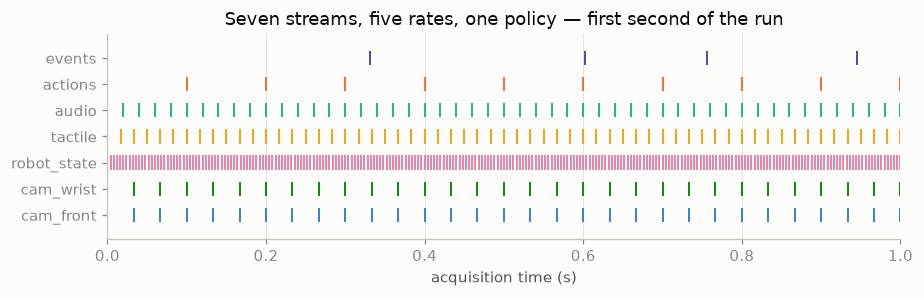

In [3]:
# First second of acquisition times: the multi-rate reality a policy frame
# has to be assembled from.
fig, ax = plt.subplots(figsize=(8.5, 2.8))
names = list(run)
for row, name in enumerate(names):
    t = [s.acquisition_time_ns / 1e9 for s in run[name] if s.acquisition_time_ns <= 1e9]
    ax.eventplot(t, lineoffsets=row, linelengths=0.55, linewidths=1.2,
                 colors=STREAM_COLORS[name])
ax.set_yticks(range(len(names)), names)
ax.set_xlim(0, 1.0)
ax.set_xlabel("acquisition time (s)")
ax.set_title("Seven streams, five rates, one policy — first second of the run")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

## 2. Inject *known* corruption

`configs/corrupt_kitchen_sink.yaml` fires every v0 corruption kind at once —
each aimed at a specific stream, all randomness derived from one profile seed:

| stream | corruption |
|---|---|
| `cam_front` | gaussian **jitter** (σ = 5 ms) + 8 % **dropped frames** |
| `cam_wrist` | +15 ms **fixed latency** + two 20 ms **burst stalls** |
| `robot_state` | 50 ppm **clock drift** + an 80 ms **missing interval** |
| `tactile` | 5 % **duplicate samples** |
| `audio` | two **non-monotonic** receive-time swaps |

`apply_profile` returns the corrupted run **plus the ground truth a real system
could never observe**: exactly which samples were removed. That sidecar is what
makes the whole pipeline falsifiable.

In [4]:
profile = load_profile(REPO / "configs" / "corrupt_kitchen_sink.yaml")
result = apply_profile(run, profile)
bad = result.run

print("ground truth (unobservable in real data):")
for name, dropped in result.dropped.items():
    print(f"  {name}: {len(dropped)} samples removed")

ground truth (unobservable in real data):
  cam_front: 13 samples removed
  robot_state: 20 samples removed


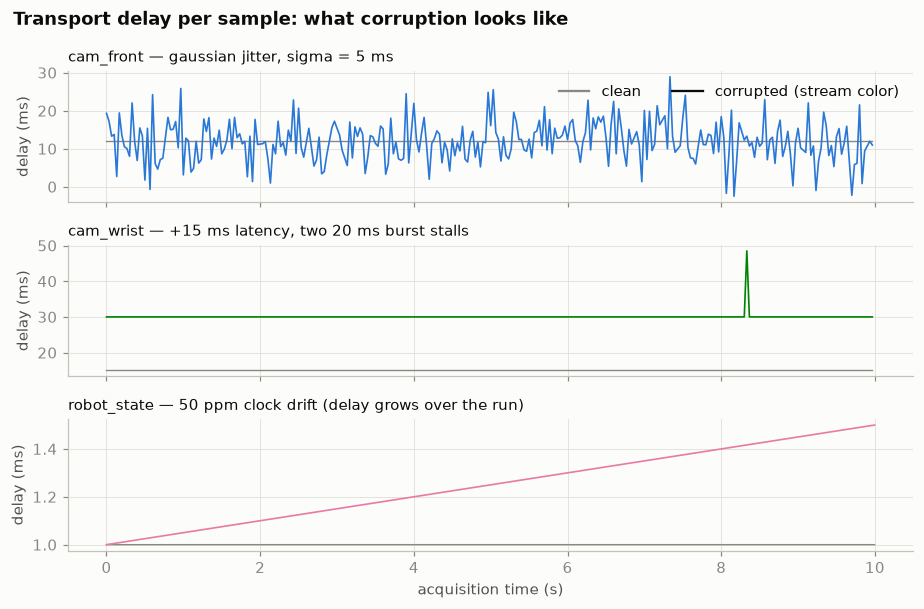

In [5]:
# Transport delay (receive - acquisition) exposes three corruptions that are
# INVISIBLE to acquisition timestamps: jitter, latency steps/stalls, drift.
panels = [
    ("cam_front", "gaussian jitter, sigma = 5 ms"),
    ("cam_wrist", "+15 ms latency, two 20 ms burst stalls"),
    ("robot_state", "50 ppm clock drift (delay grows over the run)"),
]
fig, axes = plt.subplots(3, 1, figsize=(8.5, 5.6), sharex=True)
for ax, (name, subtitle) in zip(axes, panels):
    for samples, color, lw in ((run[name], MUTED, 0.9), (bad[name], STREAM_COLORS[name], 1.1)):
        t = [s.acquisition_time_ns / 1e9 for s in samples]
        d = [(s.receive_time_ns - s.acquisition_time_ns) / MS for s in samples]
        ax.plot(t, d, color=color, linewidth=lw)
    ax.set_title(f"{name} — {subtitle}", loc="left", fontsize=10)
    ax.set_ylabel("delay (ms)")
axes[0].plot([], [], color=MUTED, label="clean")
axes[0].plot([], [], color=INK, label="corrupted (stream color)")
axes[0].legend(loc="upper right", ncols=2)
axes[-1].set_xlabel("acquisition time (s)")
fig.suptitle("Transport delay per sample: what corruption looks like", x=0.02,
             ha="left", fontweight="bold")
plt.tight_layout()
plt.show()

## 3. Align into policy-ready frames

`align_run` maps the corrupted run onto a fixed-rate target grid. Two
deliberate choices here:

- **12 Hz target** — incommensurate with every stream rate. If your policy
  tick divides your camera rate exactly (10 Hz vs 30 Hz), skew is
  identically zero *on synthetic data* and you learn nothing; real rigs are
  never that lucky, so we demo the honest case.
- **`events` is left out** — the aligned window is the *intersection* of all
  streams' acquisition windows, and a sparse marker stream (3.6 Hz,
  irregular) would narrow it and be mostly "missing" at any fixed rate.
  Real pipelines treat event markers separately from dense observations.

Every frame carries **per-stream metadata**: which source sample was picked,
its signed skew, the method, a missing flag, and a confidence derived from
skew vs. tolerance (half the median inter-sample interval). Nothing is
silently smoothed over.

In [6]:
dense = {name: samples for name, samples in bad.items() if name != "events"}
aligned = align_run(dense, target_rate_hz=12.0, method="nearest_neighbor",
                    ground_truth=result.dropped)
rep = aligned.report

print(f"frames: {len(aligned.frames)}")
print(f"{'stream':<12} {'missing':>8} {'median skew (ms)':>18}")
for name in dense:
    skew = rep.median_skew_ns[name]
    print(f"{name:<12} {rep.missing_count[name]:>8} "
          f"{'-' if skew is None else f'{skew / MS:+.3f}':>18}")

frame = aligned.frames[40]
print(f"\nframe @ t = {frame.target_time_ns / 1e9:.1f} s:")
for name, md_ in frame.metadata.items():
    skew = "-" if md_.skew_ns is None else f"{md_.skew_ns / MS:+7.2f} ms"
    print(f"  {name:<12} missing={str(md_.missing):<6} skew={skew:<12} "
          f"confidence={md_.confidence:.2f}")

frames: 119
stream        missing   median skew (ms)
cam_front           6             +0.000
cam_wrist           0             +0.000
robot_state         1             +0.000
tactile             0             +0.000
audio               0             -3.333
actions             0             +0.000

frame @ t = 3.3 s:
  cam_front    missing=False  skew=  +0.00 ms   confidence=1.00
  cam_wrist    missing=False  skew=  +0.00 ms   confidence=1.00
  robot_state  missing=False  skew=  -1.33 ms   confidence=0.33
  tactile      missing=False  skew=  +0.00 ms   confidence=1.00
  audio        missing=False  skew=  +6.67 ms   confidence=0.33
  actions      missing=False  skew= -33.33 ms   confidence=0.33


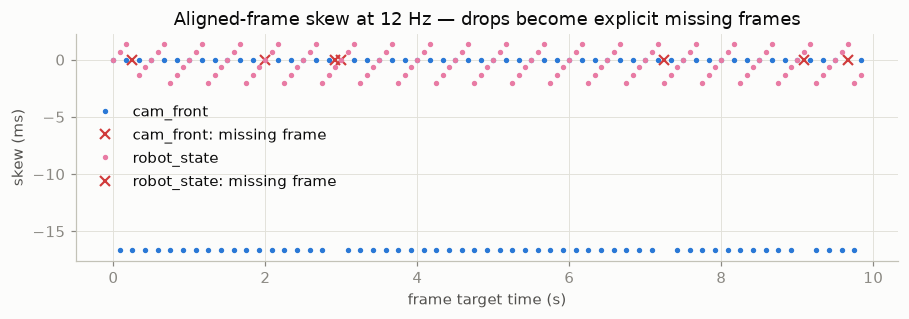

In [7]:
# Per-frame skew for the two streams whose ACQUISITION timeline was corrupted.
# Dropped frames / missing intervals surface as missing flags, not fake data.
fig, ax = plt.subplots(figsize=(8.5, 3.0))
for name in ("cam_front", "robot_state"):
    t, skew, miss_t = [], [], []
    for f in aligned.frames:
        m = f.metadata[name]
        if m.missing:
            miss_t.append(f.target_time_ns / 1e9)
        elif m.skew_ns is not None:
            t.append(f.target_time_ns / 1e9)
            skew.append(m.skew_ns / MS)
    ax.plot(t, skew, ".", markersize=5, color=STREAM_COLORS[name], label=name)
    if miss_t:
        ax.plot(miss_t, [0] * len(miss_t), "x", markersize=7, color=CRITICAL,
                markeredgewidth=1.4,
                label=f"{name}: missing frame" )
ax.set_xlabel("frame target time (s)")
ax.set_ylabel("skew (ms)")
ax.set_title("Aligned-frame skew at 12 Hz — drops become explicit missing frames")
ax.legend(loc="center left", ncols=1)
plt.tight_layout()
plt.show()

**The direction trap.** The signed *median skew* is the number to watch: it
records which way your alignment leans. Train with zero-order hold (only ever
look backward) and deploy with nearest-neighbor (symmetric), and every stream
shifts by up to half a sample period between training and deployment — with no
error anywhere.

In [8]:
zoh = align_run(dense, target_rate_hz=12.0, method="zoh")
print(f"{'stream':<12} {'NN median skew (ms)':>20} {'ZoH median skew (ms)':>22}")
for name in dense:
    nn_s, zoh_s = aligned.report.median_skew_ns[name], zoh.report.median_skew_ns[name]
    def fmt(v):
        return "-" if v is None else f"{v / MS:+.3f}"
    print(f"{name:<12} {fmt(nn_s):>20} {fmt(zoh_s):>22}")

stream        NN median skew (ms)   ZoH median skew (ms)
cam_front                  +0.000                -16.667
cam_wrist                  +0.000                -16.667
robot_state                +0.000                 -1.333
tactile                    +0.000                 +0.000
audio                      -3.333                 -6.667
actions                    +0.000                -33.333


## 4. The sync-quality report — validated against ground truth

`build_report` turns an aligned episode into per-stream statistics; `embsync
report` (or `save_report_html`) renders the same thing as a self-contained HTML
page you can attach to a dataset. Because we corrupted the data ourselves, we
can also check the aligner's *detected* missing frames against the *known*
removals — the cross-check that makes this a validation tool rather than a
dashboard.

In [9]:
report = build_report(aligned)
print(f"{'stream':<12} {'missing%':>9} {'med |skew| ms':>14} {'med conf':>9} {'gt removed':>11}")
for s in report.streams:
    mskew = "-" if s.median_abs_skew_ns is None else f"{s.median_abs_skew_ns / MS:.3f}"
    mconf = "-" if s.median_confidence is None else f"{s.median_confidence:.2f}"
    print(f"{s.name:<12} {100 * s.missing_rate:>8.1f}% {mskew:>14} {mconf:>9} "
          f"{s.ground_truth_missing_count:>11}")

out = Path("output")
out.mkdir(exist_ok=True)
html_path = save_report_html(aligned, out / "sync_report.html",
                             title="Kitchen-sink demo", target_rate_hz=12.0)
print(f"\nself-contained HTML report -> {html_path}")

stream        missing%  med |skew| ms  med conf  gt removed
cam_front         5.0%          0.000      1.00          12
cam_wrist         0.0%          0.000      1.00           0
robot_state       0.8%          1.000      0.50          20
tactile           0.0%          0.000      1.00           0
audio             0.0%          6.667      0.33           0
actions           0.0%         33.333      0.33           0

self-contained HTML report -> output/sync_report.html


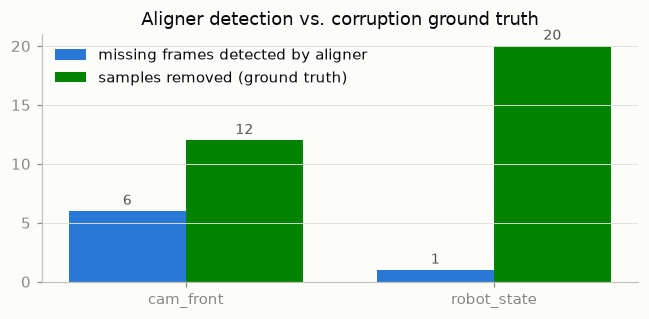

In [10]:
# Detected vs. known: streams where samples were actually removed.
streams = ["cam_front", "robot_state"]
detected = [aligned.report.missing_count[s] for s in streams]
known = [aligned.report.ground_truth_missing_count.get(s, 0) for s in streams]
x = range(len(streams))
w = 0.38
fig, ax = plt.subplots(figsize=(6.0, 3.0))
b1 = ax.bar([i - w / 2 for i in x], detected, w, color="#2a78d6",
            label="missing frames detected by aligner")
b2 = ax.bar([i + w / 2 for i in x], known, w, color="#008300",
            label="samples removed (ground truth)")
for bars in (b1, b2):
    ax.bar_label(bars, padding=2, color=INK2, fontsize=9)
ax.set_xticks(list(x), streams)
ax.grid(axis="x", visible=False)
ax.set_title("Aligner detection vs. corruption ground truth")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

The two bars measure different units on purpose — removed *samples* (250 Hz
`robot_state` loses 20 in an 80 ms hole) collapse onto the 12 Hz *frame* grid
as at most one missing frame, while `cam_front`'s scattered 8 % drops mostly
hide between frame targets. That gap between "what was destroyed" and "what a
policy would actually notice" is precisely the question the tool quantifies.

## 5. Deployment-time (online) alignment — the same metadata, causally

Offline alignment can look at the whole episode. A running policy cannot: at
tick time `now`, a sample that was *acquired* in time but *delivered* late
does not exist yet. `MultiStreamAligner` replays that constraint — push
samples in receive order, ask for a frame at each policy tick, and only
samples with `receive_time <= now` are eligible. Latency, stalls, and drift —
invisible to the offline aligner, which scores acquisition time — now bite.

In [11]:
tol = {"cam_front": 50 * MS, "cam_wrist": 50 * MS, "robot_state": 8 * MS}
online = MultiStreamAligner({n: StreamRingBuffer(capacity=512, tolerance_ns=t)
                             for n, t in tol.items()})
inbox = sorted((s for n in tol for s in bad[n]), key=lambda s: s.receive_time_ns)

i, staleness = 0, {n: [] for n in tol}
# ~10 Hz policy ticks, deliberately not phase-locked to any sensor: a real
# policy loop's clock never lines up with the camera's frame boundaries.
ticks = range(500_000_000, 9_500_000_001, 97_000_000)
for now in ticks:
    while i < len(inbox) and inbox[i].receive_time_ns <= now:
        online.push(inbox[i])
        i += 1
    f = online.get_latest_policy_frame(now)
    for n in tol:
        m = f.metadata[n]
        staleness[n].append(None if m.missing or m.source_time_ns is None
                            else (now - m.source_time_ns) / MS)

print(f"{'stream':<12} {'offline missing':>16} {'online missing':>15}")
for n in tol:
    off = sum(1 for f in aligned.frames if f.metadata[n].missing)
    on = sum(1 for v in staleness[n] if v is None)
    print(f"{n:<12} {off:>16} {on:>15}")

stream        offline missing  online missing
cam_front                   6               8
cam_wrist                   0              37
robot_state                 1               0


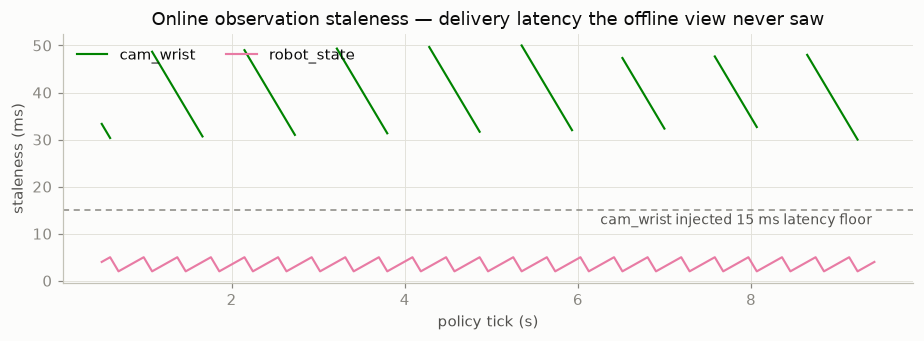

In [12]:
# Observation staleness per policy tick: how old is the newest usable sample?
fig, ax = plt.subplots(figsize=(8.5, 3.2))
t = [n / 1e9 for n in ticks]
for name in ("cam_wrist", "robot_state"):
    ax.plot(t, staleness[name], color=STREAM_COLORS[name], linewidth=1.4, label=name)
ax.axhline(15, color=MUTED, linewidth=1.0, linestyle=(0, (4, 3)))
ax.annotate("cam_wrist injected 15 ms latency floor", xy=(9.4, 15),
            xytext=(9.4, 12), ha="right", color=INK2, fontsize=9)
ax.set_xlabel("policy tick (s)")
ax.set_ylabel("staleness (ms)")
ax.set_title("Online observation staleness — delivery latency the offline view never saw")
ax.legend(loc="upper left", ncols=2)
plt.tight_layout()
plt.show()

`cam_wrist`'s sawtooth is the policy tick precessing against the 30 Hz frame
phase — but note it never touches zero: the injected 15 ms delivery latency is
a hard floor on observation freshness, and delivery stalls add occasional
extra steps. Offline alignment of the very same data reported ~zero median
skew for this stream, because acquisition timestamps were untouched. If your
training pipeline aligns offline and your robot consumes online, this gap is
part of your train/deploy shift — now it's a number instead of a hunch.

## 6. Beyond this notebook

Everything above is the *offline* half: a run already on disk. The library
also has a *live* half and a clock-recovery half, neither shown here:

- **`SyncSession`** wraps a vendor SDK's callbacks directly —
  `push`/`attach` per stream, `get()` a synchronized bundle with skew
  numbers attached, no more nearest-frame loop hand-rolled per
  integration. It records into the exact run-directory format
  `generate_synthetic_run` writes above, so this notebook's align/report
  cells apply to a live capture unchanged. See the README quickstart and
  `embodied_sync/session/session.py`'s module docstring.
- **`embodied_sync.calibrate`** recovers the offset/drift mapping between
  two real device clocks from a shared clap, QR/screen timestamp, or
  matched event train — `embsync calibrate clap` runs the audio path
  end to end. This is what turns "assume both cameras' timestamps agree"
  into a measured, confidence-scored mapping.
- **`embsync inspect-dataset` / `infer-import` / `import-auto`** handle a
  directory you don't have an adapter for: profile it, get a ranked,
  evidence-backed import plan back, then execute it — no adapter code
  written, no code generated either. See
  `docs/user/automatic_dataset_import.md`.

## 7. Using it on your data

The CLI mirrors everything above, directory-in / directory-out:

```bash
pip install -e ".[dev]"          # from a checkout; base deps: numpy + pyyaml
embsync synth   --out runs/clean --seed 0 --duration-s 10
embsync corrupt runs/clean --profile configs/corrupt_kitchen_sink.yaml --out runs/bad
embsync align   runs/bad --out episodes/bad_10hz --target-rate-hz 10 --check-ground-truth
embsync report  episodes/bad_10hz --out reports/bad.html --json-summary reports/bad.json
```

**Where the integrations stand (honest status):** the run/episode format,
corruption engine, offline + online aligners, live session, calibration
estimator, and reports are implemented and under deterministic tests.
LeRobot v3.0 and LabRecorder XDF now have real readers, not just CI
contract fixtures. MCAP and UMI still land as *contract paths* —
deterministic CI-tested surfaces — plus a true-binary MCAP read path that
preserves rosbag2 publish/log timestamps. A native UMI-zarr reader is
still open, and real-world sample datasets to test it against are exactly
what we're looking for from early users.

- Concepts: `docs/concepts/` (latency vs jitter vs drift, online vs offline alignment, timestamps and clock domains)
- Choosing a policy: `docs/user/choosing_alignment_policy.md`
- Reading reports: `docs/user/interpreting_sync_reports.md`
- Adapter authoring: `docs/developer/adapter_authoring_guide.md`
- Automatic import for unfamiliar layouts: `docs/user/automatic_dataset_import.md`